# Noise-induced dynamics: 4 trial runs, parameter set 1

Runs the 5-species Gef/Pak1 MCRD model with OU noise on (u, q) at `A = 0.01`, `tau_c = 1`
(four independent noise realizations) and plots edge traces of `u`.

All quantities are in arbitrary units. 
A full run (`T = 1000`, 2e6 steps) is slow, so results are cached to disk; set `T_FINAL` lower for a quick test.

In [4]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

for p in (Path.cwd().parent / "src", Path.cwd() / "src"):
    if p.exists():
        sys.path.insert(0, str(p))

from grid import Grid
from model import ReactionParams, solve_homogeneous_equilibrium
from solver import MCRDSolver

%matplotlib inline

## Parameter set 1

In [5]:
REACTION_PARAMS = ReactionParams(a=2.38 / 4, b=0.185, c=151.6 / 2, d=0.552, e=0.828, f=1.0)
DIFFUSION = {"u": 0.05, "q": 0.05, "v": 5.0, "w": 5.0, "p": 5.0}
N_GEF, N_PAK = 2.0, 0.492
L, N_GRID, BC = 7.0, 200, "neumann"
DT = 5e-4

A = 0.01          # integrated noise strength, A = sigma_eta^2 * tau_c
TAU_C = 1.0       # OU correlation time
N_RUNS = 4
T_FINAL = 1000.0  # lower (e.g. 50) for a quick test
PERTURBATION = 0.01  # relative amplitude of the initial perturbation

CACHE = Path(f"traces_A{A:g}_T{T_FINAL:g}.npz")  # delete to force re-simulation

## Simulate

Same model and numerics for every run; the initial condition and noise seed differ per run (seeds follow the sweep scheme: IC `3000 + rep`, noise `round(A*1e6) + rep`). A run that blows up is discarded and retried with a new seed.

In [6]:
equilibrium = solve_homogeneous_equilibrium(N_GEF, N_PAK, REACTION_PARAMS)[0]
grid = Grid(N=N_GRID, L=L, bc=BC)
solver = MCRDSolver(grid, DIFFUSION, REACTION_PARAMS, dt=DT, fp_maxiter=100)

n_steps = int(round(T_FINAL / DT))
save_every = max(1, n_steps // 1000)


def initial_condition(rng):
    u0 = np.tile(equilibrium[:, None], (1, N_GRID))
    return u0 + PERTURBATION * equilibrium[:, None] * rng.standard_normal((5, N_GRID))


if CACHE.exists():
    d = np.load(CACHE)
    times, u_runs = d["times"], d["u"]
    print("Loaded", CACHE)
else:
    u_runs = []
    for rep in range(N_RUNS):
        for attempt in range(20):
            offset = attempt * 100_000
            u0 = initial_condition(np.random.default_rng(3000 + rep + offset))
            print(f"Run {rep + 1}/{N_RUNS} (attempt {attempt}, {n_steps} steps)...")
            try:
                res = solver.run(
                    u0, n_steps, save_every=save_every, noisy=True,
                    noise_A=A, noise_tau_c=TAU_C, seed=int(round(A * 1e6)) + rep + offset,
                )
                break
            except RuntimeError:
                print("  blew up; retrying with a new seed")
        else:
            raise RuntimeError(f"Run {rep} failed 20 times")
        times = res.times
        u_runs.append(res.snapshots[:, 0, :])  # species u: (n_saved, N_GRID)
    u_runs = np.array(u_runs)
    np.savez(CACHE, times=times, u=u_runs)
    print("Saved", CACHE)

Run 1/4 (attempt 0, 2000000 steps)...
Run 2/4 (attempt 0, 2000000 steps)...
Run 3/4 (attempt 0, 2000000 steps)...
Run 4/4 (attempt 0, 2000000 steps)...
Saved traces_A0.01_T1000.npz


## Edge traces of u

Summed `u` over the outer 10% of the domain at each end (Pole 1 / Pole 2), normalized by the global maximum across runs.

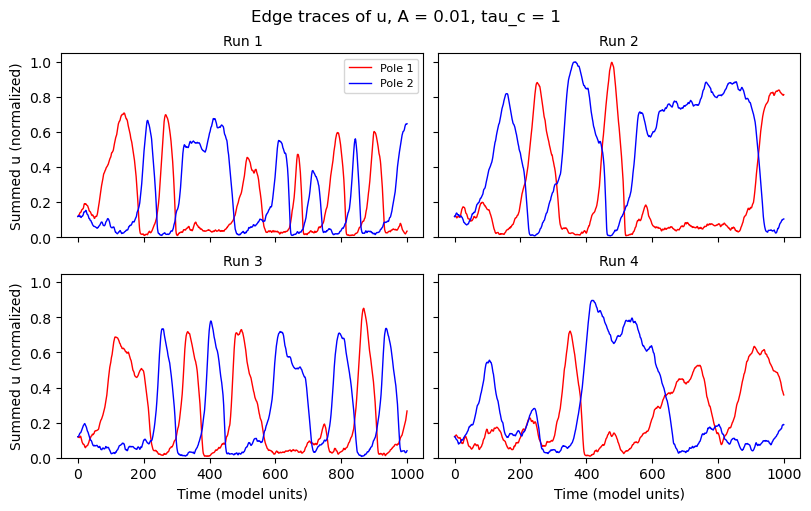

In [7]:
EDGE_FRAC = 0.1
edge_n = max(1, int(round(N_GRID * EDGE_FRAC)))
left = u_runs[:, :, :edge_n].sum(axis=2)     # (N_RUNS, n_saved)
right = u_runs[:, :, -edge_n:].sum(axis=2)
norm = max(left.max(), right.max())

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True, sharey=True, constrained_layout=True)
for rep, ax in enumerate(axes.flat):
    ax.plot(times, left[rep] / norm, color="red", lw=1, label="Pole 1")
    ax.plot(times, right[rep] / norm, color="blue", lw=1, label="Pole 2")
    ax.set_title(f"Run {rep + 1}", fontsize=10)
    ax.set_ylim(0, 1.05)
for ax in axes[1]:
    ax.set_xlabel("Time (model units)")
for ax in axes[:, 0]:
    ax.set_ylabel("Summed u (normalized)")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Edge traces of u, A = {A:g}, tau_c = {TAU_C:g}")
plt.show()